# 3_pitchfork_test

Testing results from single pitchfork

In [74]:
#### misc
import pandas as pd
import numpy as np
import os
from pathlib import Path
import pickle
import time
from itertools import product
from scipy import constants
from scipy import stats
import random
import astropy.constants
from numpy.random import default_rng

#### graphical
import matplotlib
import matplotlib.pyplot as plt

#### ML
import sklearn
from sklearn.decomposition import PCA
import tensorflow as tf
import keras
from keras import layers

#### custom
from InversePCA import InversePCA
from WMSE import WMSE, WMSE_metric

##### poke gpu
os.environ["CUDA_VISIBLE_DEVICES"]="1"

physical_devices = tf.config.list_physical_devices("GPU") 

gpu0usage = tf.config.experimental.get_memory_info("GPU:0")["current"]

print("Current GPU usage:\n"
     + " - GPU0: " + str(gpu0usage) + "B\n")

Current GPU usage:
 - GPU0: 2186752B



## 1) load in grid
keep same routine as during training

In [57]:
#### load in grid
#df_full = pd.read_hdf('/home/oxs235/datastorage/repos_data/' + str(path) + '/data/df_all_log.h5', key='df')
df_full = pd.read_hdf('/home/oxs235/datastorage/repos_data/ojscutt/pitchfork/data/keystone/bob.h5', key='df')

#### define inputs
inputs = ['log_initial_mass_std', 'log_initial_Zinit_std', 'log_initial_Yinit_std', 'log_initial_MLT_std', 'log_star_age_std']

#### define outputs
classical_outputs = ['log_radius_std', 'log_luminosity_std', 'log_surface_Z_std']
astero_outputs = ['log_nu_max_std', 'log_delta_nu_std']

outputs = classical_outputs+astero_outputs

#### train/test split
seed = 42

df_train = df_full.sample(frac=0.9, random_state=seed)
df_test = df_full.drop(df_train.index)

df_train_inputs, df_val_inputs, df_train_outputs, df_val_outputs = sklearn.model_selection.train_test_split(df_train[inputs],df_train[outputs], test_size = 0.1, random_state=seed)

print("Training set: ", len(df_train_inputs))
print("Testing set: ", len(df_test))
print("Validation set: ", len(df_val_inputs))

#### can't have too many describes
df_full.describe()


Training set:  641680
Testing set:  79220
Validation set:  71298


,initial_mass,initial_Zinit,initial_Yinit,initial_MLT,star_age,radius,luminosity,effective_T,surface_Z,nu_max,...,log_initial_Zinit_std,log_initial_Yinit_std,log_initial_MLT_std,log_star_age_std,log_radius_std,log_luminosity_std,log_effective_T_std,log_surface_Z_std,log_nu_max_std,log_delta_nu_std
count,792198.000000,792198.000000,792198.000000,792198.000000,792198.000000,792198.000000,792198.000000,792198.000000,792198.000000,792198.000000,...,7.921980e+05,7.921980e+05,7.921980e+05,7.921980e+05,7.921980e+05,7.921980e+05,7.921980e+05,7.921980e+05,7.921980e+05,7.921980e+05
mean,1.032772,0.017551,0.278219,1.800823,4.819359,1.151215,1.617280,5882.540532,0.015335,2668.940264,...,2.029420e-15,2.871597e-15,-3.906865e-15,-8.005959e-17,-3.372441e-17,-2.367884e-17,-1.117476e-14,-1.805476e-15,-1.563090e-15,3.756325e-15
std,0.103474,0.010244,0.022917,0.115516,3.459256,0.255999,1.031820,472.426889,0.009956,925.630210,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,0.800000,0.004004,0.240020,1.600098,0.018656,0.687935,0.271118,4701.918937,0.000323,763.276107,...,-1.978866e+00,-1.750248e+00,-1.804411e+00,-4.430341e+00,-2.331268e+00,-2.590249e+00,-2.767900e+00,-3.581863e+00,-3.071945e+00,-3.098951e+00
25%,0.952000,0.008522,0.258311,1.701172,2.003543,0.962485,0.850404,5532.257625,0.006906,1963.104691,...,-8.152904e-01,-8.593967e-01,-8.525382e-01,-3.959378e-01,-7.398188e-01,-7.382142e-01,-7.294871e-01,-4.760246e-01,-6.201559e-01,-6.153846e-01
50%,1.042000,0.015451,0.277295,1.801318,4.165208,1.101051,1.356173,5848.726977,0.013637,2649.618353,...,1.011573e-01,8.491942e-04,3.637859e-02,2.354230e-01,-1.024183e-01,1.790694e-02,-3.222205e-02,2.139363e-01,1.581779e-01,1.624791e-01
75%,1.119000,0.025461,0.297773,1.900928,7.085151,1.284915,2.107733,6207.138200,0.022965,3343.707797,...,8.703738e-01,8.651243e-01,8.727972e-01,6.937153e-01,6.294013e-01,7.322872e-01,7.132740e-01,7.425388e-01,7.620387e-01,7.535334e-01
max,1.200000,0.039924,0.319990,1.999951,13.999716,2.073636,9.833521,7732.911306,0.039918,5388.566188,...,1.563217e+00,1.737967e+00,1.661935e+00,1.281240e+00,2.897512e+00,3.227549e+00,3.468157e+00,1.303204e+00,2.000567e+00,2.124895e+00


In [58]:
def calc_Teff(luminosity, radius):
    return np.array(((luminosity.values*astropy.constants.L_sun) / (4*np.pi*constants.sigma*((radius.values*astropy.constants.R_sun)**2)))**0.25)

def rescale_preds(preds, df, column):
    if 'star_feh' in column:
        return (preds[column+"_std"]*df[column].std())+df[column].mean()
    else:
        return 10**((preds["log_"+column+"_std"]*df["log_"+column].std())+df["log_"+column].mean())

## Testing results from pitchfork


In [59]:
"""
load in angry mob
"""
pitchfork_name = "barbie1"
pitchfork = tf.keras.models.load_model("/home/oxs235/datastorage/repos_data/ojscutt/pitchfork/models/keystone/" + pitchfork_name + ".h5")


In [60]:
#### define inputs
inputs = ['log_initial_mass_std', 'log_initial_Zinit_std', 'log_initial_Yinit_std', 'log_initial_MLT_std', 'log_star_age_std']

#### define outputs
classical_outputs = ['log_radius_std', 'log_luminosity_std', 'log_surface_Z_std']
astero_outputs = ['log_nu_max_std', 'log_delta_nu_std']

pred_outputs = classical_outputs+astero_outputs

outputs = ['radius', 'luminosity', 'surface_Z', 'nu_max', 'delta_nu']

preds = pitchfork(np.array(df_test[inputs]))

preds_df = pd.DataFrame(np.concatenate((np.array(preds[0]),np.array(preds[1])), axis=1), columns=pred_outputs)


for output in outputs:
    preds_df[output] = rescale_preds(preds_df, df_full, output)

preds_df['effective_T'] = calc_Teff(preds_df["luminosity"],preds_df["radius"])

pitchfork_errors_df=pd.DataFrame(np.array(df_test[outputs+['effective_T']]) - np.array(preds_df[outputs+['effective_T']]), columns=[outputs+['effective_T']])

In [61]:
pitchfork_errors_df

,radius,luminosity,surface_Z,nu_max,delta_nu,effective_T
0,0.000164,-0.002170,0.000038,3.718620,-0.006707,3.399899
1,0.000067,0.000008,-0.000012,-0.609320,0.053618,7.655222
2,0.000139,0.000354,-0.000012,-0.285658,0.056781,7.999001
3,0.000348,0.001981,-0.000025,-6.939984,-0.162327,9.953827
4,0.000761,0.000936,-0.000031,-4.742637,-0.099810,6.824230
...,...,...,...,...,...,...
79215,0.000671,-0.004764,-0.000017,-5.329140,-0.299700,3.471689
79216,0.001174,0.006701,-0.000007,-2.883919,-0.173963,9.756745
79217,0.001303,-0.000166,0.000032,0.646312,0.060392,5.390309
79218,0.002646,0.005336,0.000023,0.433542,0.058049,5.373267


In [77]:
def output_plot(output, target_unc, axis, color):
    errors = pitchfork_errors_df[output]
    errors_mad = stats.median_abs_deviation(errors)
    print(output + " MAD: " + str(errors_mad))
    errors_med = np.median(errors)
    
    axis.hist(errors, bins=500, color=color)
    #axis.axvline(target_unc, linestyle='dashed', color='black')
    #axis.axvline(-target_unc, linestyle='dashed', color='black')
    axis.axvline(0, color='black')
    axis.axvline(errors_med + errors_mad, color='orange')
    axis.axvline(errors_med -errors_mad, color='orange')
    axis.set_xlim(-5*errors_mad, 5*errors_mad)
    # if errors_mad > target_unc:
    #     axis.set_xlim(-5*errors_mad, 5*errors_mad)
    # else:
    #     axis.set_xlim(-3*target_unc, 3*target_unc)
    axis.set_title(output)
    axis.set_yticks([])

def pitchfork_eval(pitchfork, df_test, color):
    #### define inputs
    inputs = ['log_initial_mass_std', 'log_initial_Zinit_std', 'log_initial_Yinit_std', 'log_initial_MLT_std', 'log_star_age_std']

    #### define outputs
    classical_outputs = ['log_radius_std', 'log_luminosity_std', 'log_surface_Z_std']
    astero_outputs = ['log_nu_max_std', 'log_delta_nu_std']

    pred_outputs = classical_outputs+astero_outputs

    outputs = ['radius', 'luminosity', 'surface_Z', 'nu_max', 'delta_nu']
    
    preds = pitchfork(np.array(df_test[inputs]))
    
    preds_df = pd.DataFrame(np.concatenate((np.array(preds[0]),np.array(preds[1])), axis=1), columns=pred_outputs)
    
    for output in outputs:
        preds_df[output] = rescale_preds(preds_df, df_full, output)
    
    preds_df['effective_T'] = calc_Teff(preds_df["luminosity"],preds_df["radius"])
    
    pitchfork_errors_df=pd.DataFrame(np.array(df_test[outputs+['effective_T']]) - np.array(preds_df[outputs+['effective_T']]), columns=[outputs+['effective_T']])

    fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(20,10))

    output_plot('radius', 0.01, ax1,color)
    ax1.set_xlabel('$R_{\odot}$')

    output_plot('luminosity', 0.02, ax2,color)
    ax2.set_xlabel('$L_{\odot}$')
    
    output_plot('effective_T', 5, ax3,color)
    ax3.set_xlabel('$K$')

    output_plot('surface_Z', 0.0001, ax4,color)
    ax4.set_xlabel('')

    output_plot('delta_nu', 0.01, ax5,color)
    ax5.set_xlabel('$\mu Hz$')

    output_plot('nu_max', 0.01, ax6,color)
    ax6.set_xlabel('$\mu Hz$')

radius MAD: [0.00063489]
luminosity MAD: [0.00209376]
effective_T MAD: [2.54618188]
surface_Z MAD: [2.85273329e-05]
delta_nu MAD: [0.07026176]
nu_max MAD: [2.06523303]


Text(0.5, 0.95, 'barbie net, barbie grid')

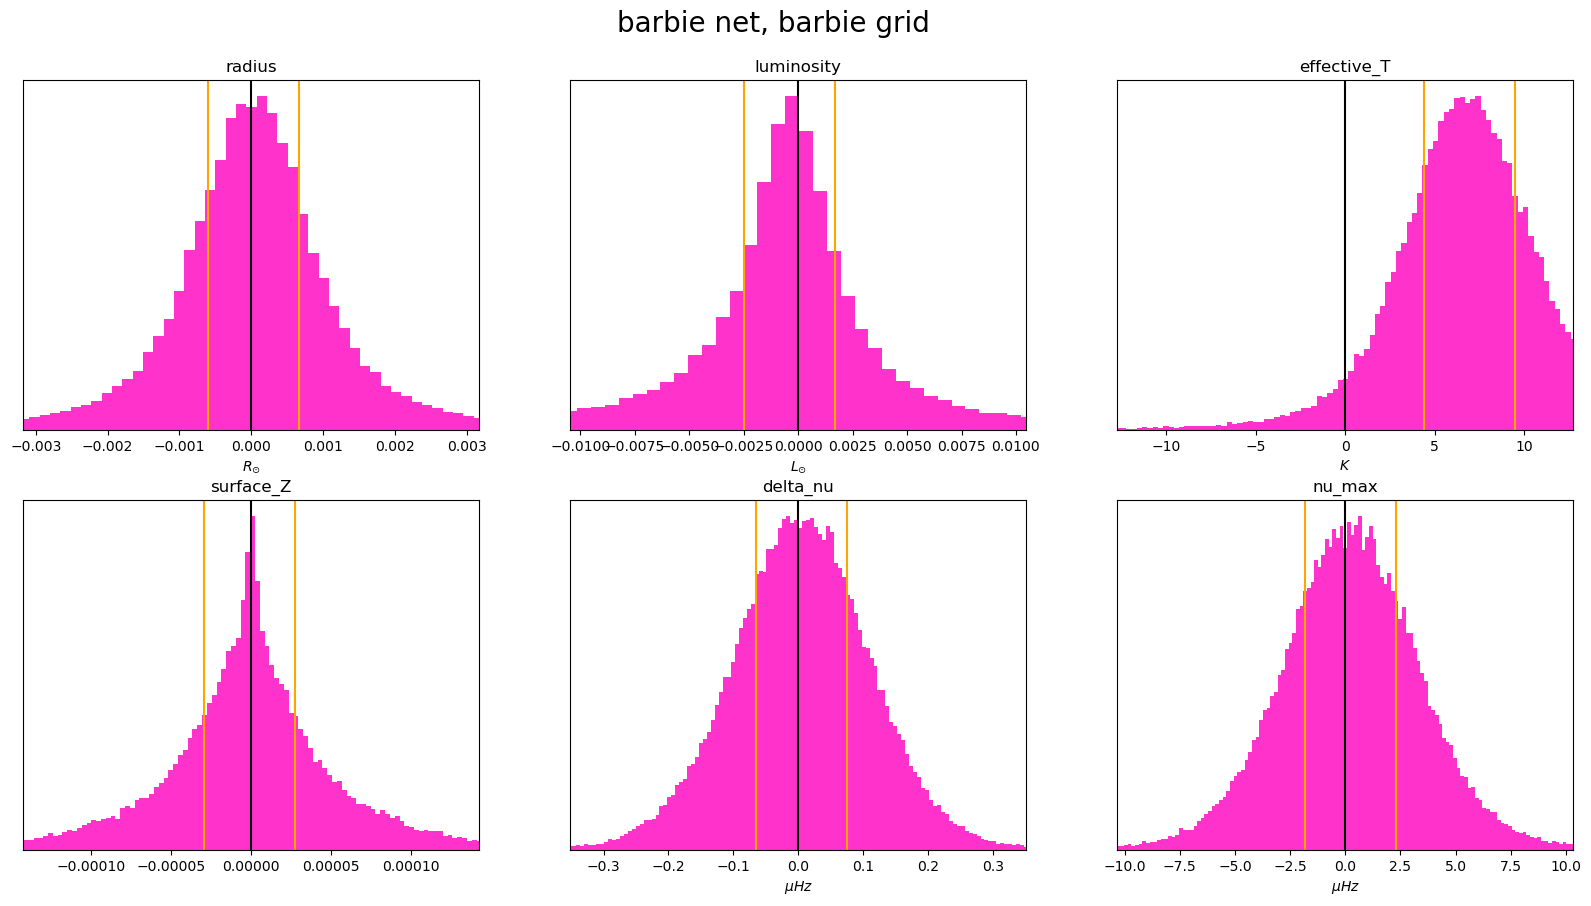

In [78]:
cmap = matplotlib.colormaps.get_cmap('spring')

rgba = cmap(0.2)

pitchfork_eval(pitchfork, df_test, rgba)
plt.suptitle("barbie net, barbie grid", y=0.95, fontsize=20)

radius MAD: [0.05735279]
luminosity MAD: [0.11085856]
effective_T MAD: [141.27310501]
surface_Z MAD: [0.00188138]
delta_nu MAD: [6.54939416]
nu_max MAD: [159.21172142]


Text(0.5, 0.95, 'barbie net, bob grid')

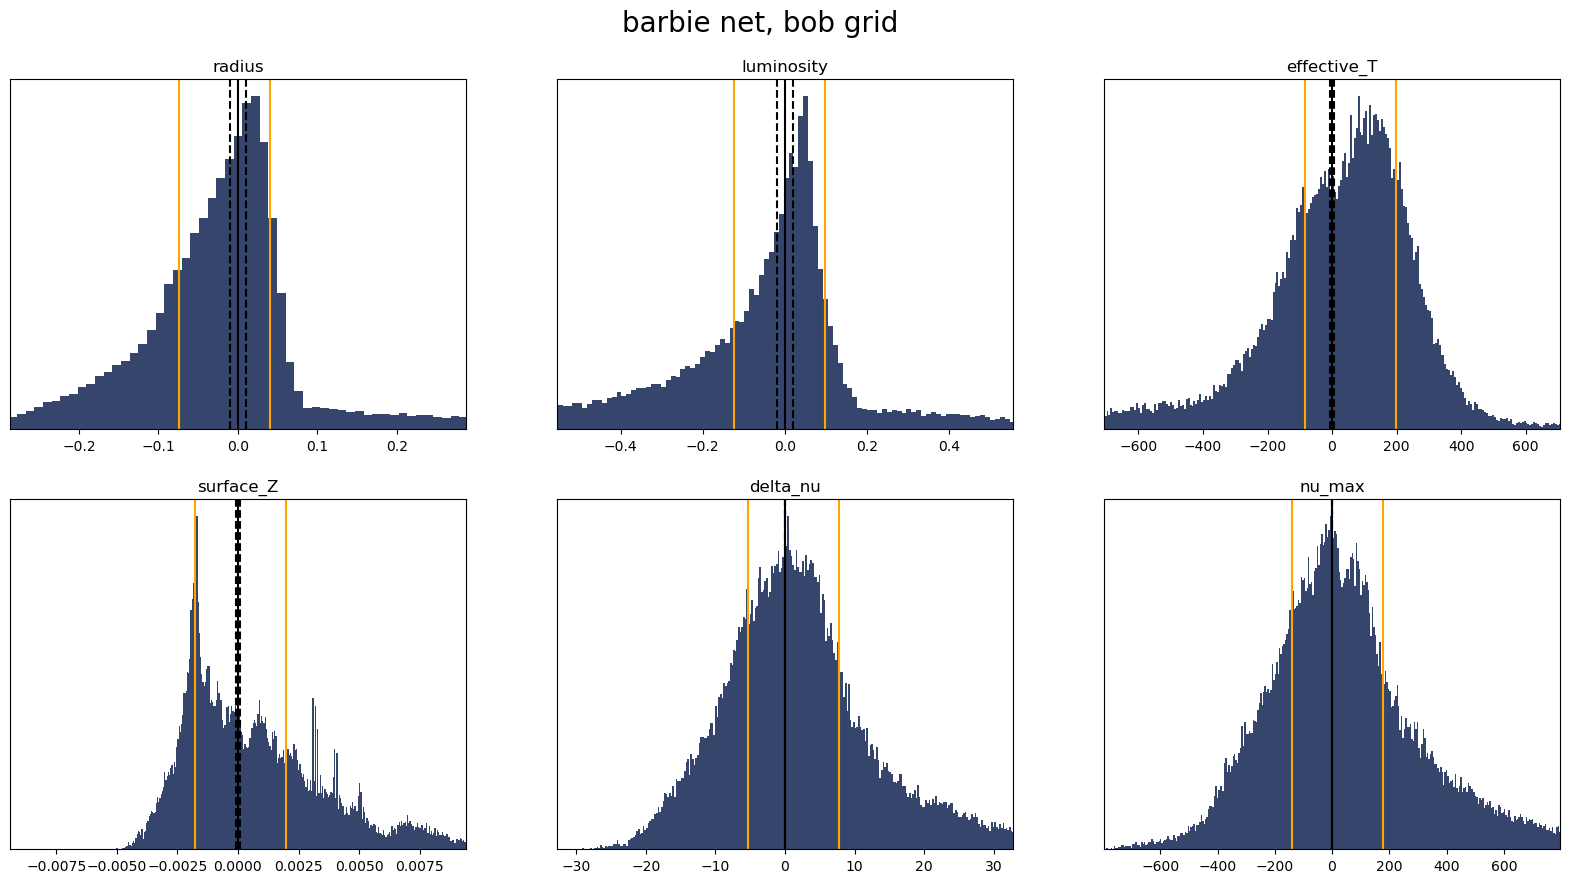

In [50]:
cmap = matplotlib.colormaps.get_cmap('cividis')

rgba = cmap(0.2)

pitchfork_eval(pitchfork, df_test, rgba)
plt.suptitle("barbie net, bob grid", y=0.95, fontsize=20)